In [8]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

Set up: Models, data, etc.

In [9]:
sampler = "Pathfinder"

plot_color = '#175449'

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'

data_dir = '../../../results/param_est/kinase_KO/std_dcr/'
save_dir_base = '../../../results/predictions/stimulus_strength/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")


# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

MM_non_all = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = dfrx.ODETerm(MM_non_all.prescribe_Ca_ATP_flux)

width= 1.5
height= 1.25

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [10]:
# func to compute time to half max
# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed

def ramp_signal(times, start_level, end_level, ramp_duration, start_time=0, reverse=False):
    """
    Generate a ramp signal starting at a specified time, with an option to reverse the ramp.

    Parameters:
    times (array): Array of time points.
    start_level (float): The starting value of the ramp.
    end_level (float): The ending value of the ramp.
    ramp_duration (float): Duration of the ramp.
    start_time (float): The time at which the ramp starts.
    reverse (bool): If True, the ramp will go back down after reaching the end level.

    Returns:
    array: Array of the same length as times with the ramp signal.
    """
    slope = (end_level - start_level) / ramp_duration
    ramp_up = start_level + slope * (times - start_time)
    ramp_up = jax.numpy.where(times < start_time, start_level, ramp_up)
    ramp_up = jax.numpy.where(times > start_time + ramp_duration, end_level, ramp_up)

    if reverse:
        ramp_down = end_level - slope * (times - (start_time + ramp_duration))
        ramp_down = jax.numpy.where(times <= start_time + ramp_duration, end_level, ramp_down)
        ramp_down = jax.numpy.where(times > start_time + 2 * ramp_duration, start_level, ramp_down)
        return jax.numpy.where(times > start_time + ramp_duration, ramp_down, ramp_up)

    return ramp_up

def step_signal(times, step_time, start_level, end_level, reverse=False, reverse_time=None):
    """
    Generate a step signal that changes from start_level to end_level at a specified time,
    with an option to reverse back to the start_level at a later time.

    Parameters:
    times (array): Array of time points.
    step_time (float): The time at which the step occurs.
    start_level (float): The value before the step.
    end_level (float): The value after the step.
    reverse (bool): If True, the signal will reverse back to start_level.
    reverse_time (float): The time at which the signal reverses back to start_level.

    Returns:
    array: Array of the same length as times with the step signal.
    """
    signal = jax.numpy.where(times < step_time, start_level, end_level)
    if reverse and reverse_time is not None:
        signal = jax.numpy.where(times >= reverse_time, start_level, signal)
    return signal

def ramp_hold_signal(times, start_level, end_level, ramp_duration, hold_duration, start_time=0):
    """
    Generate a signal that ramps up, holds at a high level, and then ramps back down.

    Parameters:
    times (array): Array of time points.
    start_level (float): The starting value of the signal.
    end_level (float): The peak value of the signal.
    ramp_duration (float): Duration of the ramp up and ramp down.
    hold_duration (float): Duration to hold the signal at the peak value.
    start_time (float): The time at which the ramp starts.

    Returns:
    array: Array of the same length as times with the ramp-hold signal.
    """
    slope = (end_level - start_level) / ramp_duration
    ramp_up = start_level + slope * (times - start_time)
    ramp_up = jax.numpy.where(times < start_time, start_level, ramp_up)
    ramp_up = jax.numpy.where(times > start_time + ramp_duration, end_level, ramp_up)

    hold_start = start_time + ramp_duration
    hold_end = hold_start + hold_duration
    hold = jax.numpy.where((times >= hold_start) & (times <= hold_end), end_level, ramp_up)

    ramp_down = end_level - slope * (times - hold_end)
    ramp_down = jax.numpy.where(times <= hold_end, hold, ramp_down)
    ramp_down = jax.numpy.where(times > hold_end + ramp_duration, start_level, ramp_down)

    return ramp_down

def dynamic_stim(params, rhs, y0, times, Ca_func, kHydro_func, Ca_basal, kHydro_basal,
        tmax_init=1e3, rtol=1e-6, atol=1e-6, pcoeff=0.3, 
        icoeff=0.4, dcoeff=0.0, dt0=1e-10, solver = dfrx.Kvaerno5()):
    """ Function to solve the ODE with dynamic stimuli. The time-dependent RHS func expercts functions for the Ca2+ concentration and kHydro rate as the final two params in the params list (calcium first, then kHydro)."""
    
    # solver details
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    # max_steps=int(3)

    # first equilibrate the system with basal conditions
    ca_basal_func = lambda t: Ca_basal
    kHydro_basal_func = lambda t: kHydro_basal

    basal_params = list(params.copy())
    basal_params.append(ca_basal_func)
    basal_params.append(kHydro_basal_func)

    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, 
        y0, 
        args=basal_params,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        throw=True)
    
    # now apply the dynamic stimuli
    stim_params = list(params.copy())
    stim_params.append(Ca_func)
    stim_params.append(kHydro_func)

    # run the simulation
    sol_stressed = dfrx.diffeqsolve(
        rhs, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=stim_params, 
        saveat=saveat,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        max_steps=None,
        throw=False)
    
    return jnp.squeeze(jnp.array(sol_stressed.ys))

def compute_pAMPK_activity(sol, param, pampk_idxs=np.array([10, 15, 16]), amp_pampk_idx=14):
    return sol[pampk_idxs, :].sum(axis=0)*param[12] + sol[amp_pampk_idx, :]*param[12]*param[24]

def plot_barplot(data_df, x_name, y_name, x_label, y_label, fig_width, fig_height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0):
    fig, ax = get_sized_fig_ax(fig_width, fig_height)

    sns.barplot(data=data_df, x=x_name, y=y_name, 
            color=plot_color, ax=ax, edgecolor='black', alpha=0.75,
            errorbar='sd',err_kws={'color': 'black'})
    if invert_x:
        ax.invert_xaxis()
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

    if xticklabs is not None:
        ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
    
    ax.tick_params(axis='both', which='major', labelsize=8)


    return fig, ax

### Single step function of increase Ca2+ and ATP fluxes from baseline to something similar to the exercise model preds

We will start by simulating for one minute

#### Ca2+ flux
Base is zero in the exercise model
Maximum is near 5e4 uM/s

#### ATP Flux
Baseline ATP flux at IC is 1.23 mM/s
Values from exercise model are on the order of 2-2.25e3 uM/s with baselines near 5e2 uM/s

#### Levels to simulate
1. Baseline
2. 100 uM/s Ca2+ flux, 0.1 mM/s ATP flux
3. 500 uM/s Ca2+ flux, 0.5 mM/s ATP flux
4. 1000 uM/s Ca2+ flux, 1.0 mM/s ATP flux
5. 2000 uM/s Ca2+ flux, 2.0 mM/s ATP flux
6. 5000 uM/s Ca2+ flux, 5.0 mM/s ATP flux

#### Timing
begin with a 5 second (0.2 Hz) step function

In [11]:
nsamples=40
params = get_param_subsample(param_names, idata_cyto, nsamples) # one param for now, then draw a random subset

Now define time-dependent functions for the Ca2+ and ATP fluxes

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1465865792.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_in.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1465865792.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'kHydro_flux.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.c

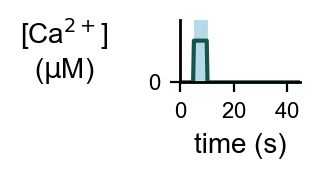

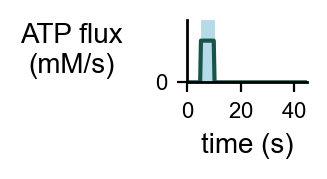

In [12]:
tsim = np.linspace(0, 600, 2000)

Ca_flux = lambda t, stim_level: step_signal(t, 5, 0.0, stim_level, reverse=True,
                                            reverse_time=10)

# + \
#                                 step_signal(t, 10, 0.0, -1*stim_level, reverse=True,
#                                             reverse_time=15) 

kHydro = lambda t, stim_level: step_signal(t, 5, 0.0, stim_level, reverse=True,
                                            reverse_time=10)

fig, ax = get_sized_fig_ax(width/2.5, height/4)
ax.plot(tsim, Ca_flux(tsim, 1), color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, 45)
ax.set_ylim(0, 1.5)
ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel(r'[Ca$^{2+}$]'+'\n'+r'($\mu$M)', fontsize=10, rotation=0, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 10, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_in.pdf', bbox_inches='tight', transparent=True)

fig, ax = get_sized_fig_ax(width/2.5, height/4)
ax.plot(tsim, kHydro(tsim, 1), color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, 45)
ax.set_ylim(0, 1.5)
ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel('ATP flux\n(mM/s)', fontsize=10, rotation=0, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 10, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'kHydro_flux.pdf', bbox_inches='tight', transparent=True)


In [13]:
# fig, ax = plt.subplots(1, 1, figsize=(5, 3))
# ax.plot(times, Ca_pulse(times), color=plot_color, lw=2)
Ca_end = 1
kHydro_end = 0.1

@jax.jit
def compute_pAMPK_act_AUC(ca_end, kHydro_end, param):

    Ca_stim_basal = lambda t: 0.1
    ATP_hydo_basal = lambda t: 0.0
    Ca_stim = lambda t: 0.1 + Ca_flux(t, ca_end)    
    kHydro_stim = lambda t: kHydro(t, kHydro_end)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC = jax.vmap(compute_pAMPK_act_AUC, in_axes=(None, None, 0))

In [14]:
test_auc, act,sol = compute_pAMPK_act_AUC(0.1, 1e-2, params[0])
print("AUC: ", test_auc)

AUC:  0.5796179972037356


In [30]:
stims = {
    'Ca':     [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5,1.0],
    'kHydro': [0,1e-2, 1e-1, 5e-1, 1e0, 2e0, 5e0]
}

auc_vals = {}
acts = []
sols = {}
for i in range(len(stims['Ca'])):
    auc_inner = {}
    sols_inner = {}
    ca_end = stims['Ca'][i]
    for j in range(len(stims['kHydro'])):
        kHydro_end = stims['kHydro'][j]

        # compute the AUC
        auc, pAMPK_act, sol = vmap_compute_pAMPK_act_AUC(ca_end, kHydro_end, params)
        
        auc_inner[kHydro_end] = auc
        sols_inner[kHydro_end] = sol
    auc_vals[ca_end] = auc_inner
    sols[ca_end] = sols_inner

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/4244199895.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_barplot.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


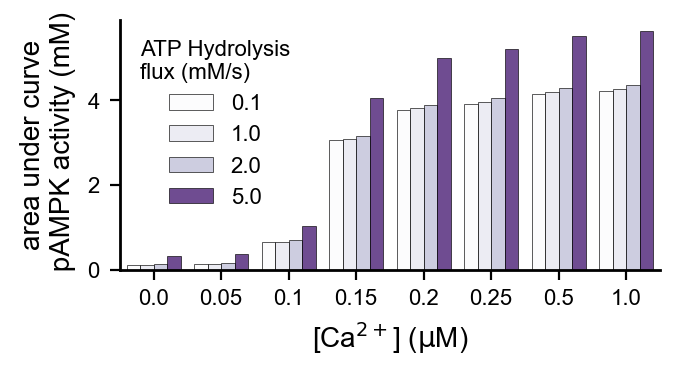

In [16]:
# Convert to DF and compute AUC means
df_vals = pd.DataFrame.from_dict(auc_vals)
df_vals_long = df_vals.reset_index().melt(id_vars='index', var_name='Ca', value_name='AUC')
df_vals_long = df_vals_long.rename(columns={'index': 'kHydro'})
df_vals_long['AUC'] = df_vals_long['AUC'].apply(lambda x: np.mean(x))

# Convert Ca and kHydro columns to float for sorting and plotting
df_vals_long['Ca'] = df_vals_long['Ca'].astype(float)
df_vals_long['kHydro'] = df_vals_long['kHydro'].astype(float)
df_vals_long['AUC'] = df_vals_long['AUC'].astype(float)

k_hydros_to_plot = [0.1, 1.0, 2.0, 5.0]
df_vals_long = df_vals_long[df_vals_long['kHydro'].isin(k_hydros_to_plot)]

fig, ax = get_sized_fig_ax(1.8*width, height)
sns.barplot(data=df_vals_long, x='Ca', y='AUC', hue='kHydro', ax=ax, 
            palette="Purples", edgecolor='black', alpha=0.75, errorbar='sd', 
            err_kws={'color': 'black'})

ax.set_xlabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
ax.set_ylabel('area under curve\n pAMPK activity (mM)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.legend(title='ATP Hydrolysis\nflux (mM/s)', fontsize=8, title_fontsize=8)

fig.savefig(save_dir + 'AUC_barplot.pdf', bbox_inches='tight', transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/3035309846.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_to_plot = pd.concat([df_to_plot, max_vals_tmp], ignore_index=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/3035309846.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + AXPs[i] + '_conc_barplot.pdf', bbox_inches='tight',
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/3035309846.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the re

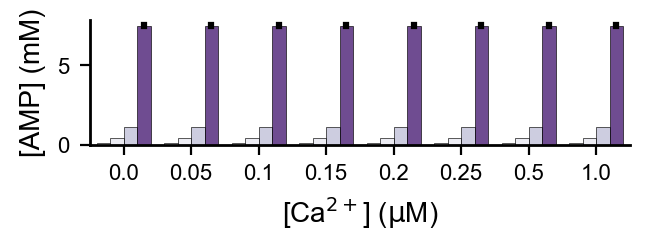

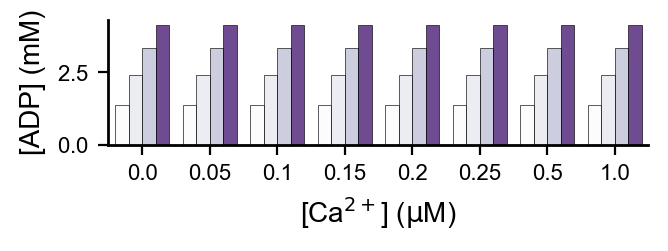

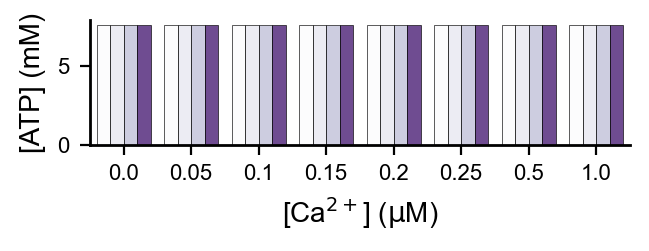

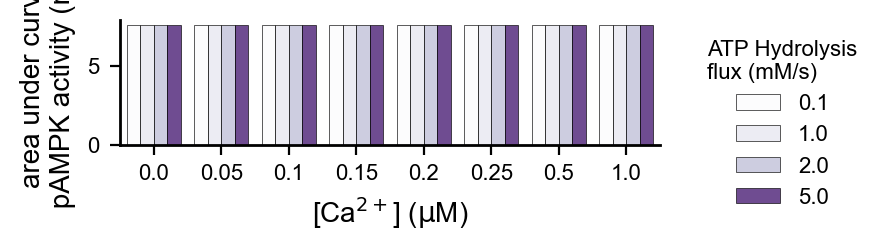

In [60]:
# first need to build up a dataframe for the max AMP, ADP and ATP concentrations at each Ca concentration and each of the four kHyrdo to plot
k_hydros_to_plot = [0.1, 1.0, 2.0, 5.0]
AXPs = ['AMP', 'ADP', 'ATP']
for i in range(3): # iterate over AMP, ADP, ATP
    df_to_plot = pd.DataFrame(columns=['AXP_conc','ca','kHydro'])
    for kHydro in k_hydros_to_plot:
        for ca in stims['Ca']:
            
            sol = sols[ca][kHydro]
            AXP = list(map(float, sol[:, i, :].max(axis=1)))

            max_vals_tmp = pd.DataFrame({
                'ca': [ca] * len(AXP),
                'AXP_conc': AXP,
                'kHydro': [kHydro] * len(AXP)
            })
            df_to_plot = pd.concat([df_to_plot, max_vals_tmp], ignore_index=True)

    # now plot the data
    fig, ax = get_sized_fig_ax(1.8*width, height/2)
    sns.barplot(data=df_to_plot, x='ca', y='AXP_conc', hue='kHydro', ax=ax, 
                palette="Purples", edgecolor='black', alpha=0.75, errorbar='sd', 
                err_kws={'color': 'black'})

    ax.set_xlabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
    ax.set_ylabel('[' + AXPs[i] + '] (mM)', fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.legend().remove()
    fig.savefig(save_dir + AXPs[i] + '_conc_barplot.pdf', bbox_inches='tight', 
                transparent=True)


# extra plot for legend
# now plot the data
fig, ax = get_sized_fig_ax(1.8*width, height/2)
sns.barplot(data=df_to_plot, x='ca', y='AXP_conc', hue='kHydro', ax=ax, 
            palette="Purples", edgecolor='black', alpha=0.75, errorbar='sd', 
            err_kws={'color': 'black'})

ax.set_xlabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
ax.set_ylabel('area under curve\n pAMPK activity (mM)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
leg = ax.legend(title='ATP Hydrolysis\nflux (mM/s)', fontsize=8, title_fontsize=8,
          bbox_to_anchor=(1.05, 1), loc='upper left')
export_legend(leg, save_dir + 'AXP_conc_legend.pdf')


/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1211698090.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig_cb.savefig(save_dir + 'AUC_heatmap_colorbar.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1211698090.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_heatmap.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might 

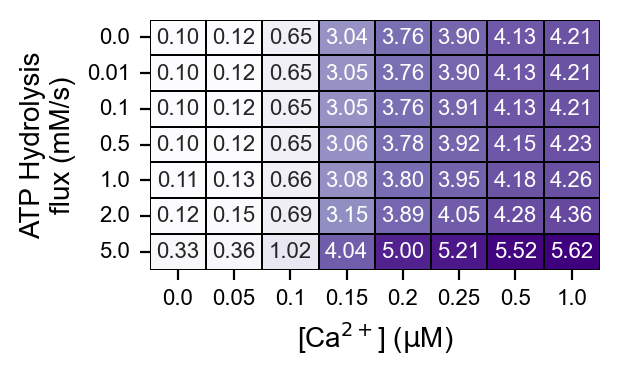

/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


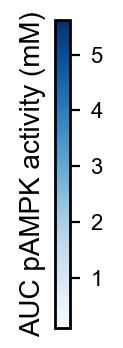

In [17]:
df_vals = pd.DataFrame.from_dict(auc_vals)
df_vals_long = df_vals.reset_index().melt(id_vars='index', var_name='Ca', value_name='AUC')
df_vals_long = df_vals_long.rename(columns={'index': 'kHydro'})
df_vals_long['AUC'] = df_vals_long['AUC'].apply(lambda x: np.mean(x))

# Convert Ca and kHydro columns to float for sorting and plotting
df_vals_long['Ca'] = df_vals_long['Ca'].astype(float)
df_vals_long['kHydro'] = df_vals_long['kHydro'].astype(float)
df_vals_long['AUC'] = df_vals_long['AUC'].astype(float)

# Pivot the dataframe for heatmap
heatmap_data = df_vals_long.pivot(index='kHydro', columns='Ca', values='AUC')

fig, ax = get_sized_fig_ax(1.5*width, height)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Purples", ax=ax, annot_kws={'fontsize':8},
            cbar=False, linewidths=0.1, linecolor='black')
ax.set_xlabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=10)
ax.set_ylabel('ATP Hydrolysis\nflux (mM/s)', fontsize=10)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontsize(8)

# Save the colorbar as its own PDF
fig_cb, ax_cb = plt.subplots(figsize=(0.1, 2.0))
norm = plt.Normalize(df_vals_long['AUC'].min(), df_vals_long['AUC'].max())
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical')
# Move the label to the right side of the colorbar (default is right)
# To move it to the left, use the 'labelposition' argument
cbar.set_label('AUC pAMPK activity (mM)', fontsize=10, labelpad=-30)
cbar.ax.tick_params(labelsize=8)

fig_cb.savefig(save_dir + 'AUC_heatmap_colorbar.pdf', bbox_inches='tight', transparent=True)
# plt.close(fig_cb)

# plt.show()

fig.savefig(save_dir + 'AUC_heatmap.pdf', bbox_inches='tight', transparent=True)

Bar chart of pAMPK activity AUC vs stim size

In [18]:
# fig, ax = get_sized_fig_ax(width, height)

# for i in range(len(stims['kHydro'])):
#     tmp = acts[i][0].mean(axis=0)
#     ax.plot(tsim/60, (tmp - tmp[0])*1000, lw=2, label=str(stims['Ca'][i]))

# # ax.legend()
# ax.set_xlim(0, 2)
# # ax.set_ylim(0, 0.0105)
# ax.axvspan(5, 10, color='lightblue', alpha=0.9, zorder=0)
# ax.set_xlabel('time (min)', fontsize=10)
# ax.set_ylabel('pAMPK activity\n' + r'($\mu$M/s)', fontsize=10)
# ax.set_yticks([0.0, 4, 8])


In [19]:
# dat_df = pd.DataFrame(auc_vals, columns=['AUC'])

# # Add kHydro and Ca columns
# for i in range(len(stims['kHydro'])):
#     dat_df.loc[i, 'kHydro'] = stims['kHydro'][i]
#     dat_df.loc[i, 'Ca'] = stims['Ca'][i]

# # Expand the dataframe to have one row per replicate
# dat_df_expanded = dat_df.explode('AUC').reset_index(drop=True)
# dat_df_expanded['replicates'] = 0

# # Assign replicate index (starting from 1) for each group
# for i in range(len(stims['kHydro'])):
#     n_reps = len(dat_df.loc[i, 'AUC'])
#     dat_df_expanded.loc[dat_df_expanded.index[sum(len(dat_df.loc[j, 'AUC']) for j in range(i)):sum(len(dat_df.loc[j, 'AUC']) for j in range(i+1))], 'replicates'] = range(1, n_reps+1)

# dat_df = dat_df_expanded

# dat_df['AUC'] = dat_df['AUC'].astype(float)

# fig, ax = plot_barplot(dat_df, 'Ca', 'AUC', 'Ca', 'AUC', width, height, 
#                  plot_color, invert_x=False, xticklabs=None,
#                                rot_angle=0)

# xticklabs = ['0.1, 1e-4', '0.25, 2.5e-4', '0.5, 5e-4', '1.0, 1e-3', '10.0, 1e-2', '100.0, 1e-1']
# ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
# ax.set_xlabel(r'Ca$^{2+}$ flux, ATP flux'+'\n' + r'($\mu$M/s, mM/s)', fontsize=10)
# ax.set_ylabel('AUC: pAMPK\nactivity (mM)', fontsize=10)

# fig.savefig(save_dir + 'AUC_pAMPK_activity_5sec.pdf', bbox_inches='tight', transparent=True)

Small plots of Ca and ATP concentration vs time

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/2417935677.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'pAMPK_act.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/2417935677.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'ATP.pdf', bbox_inches='tight', transparent=True)


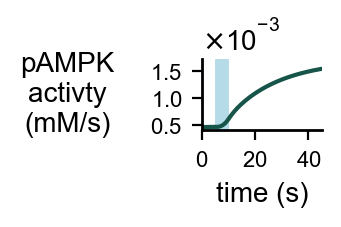

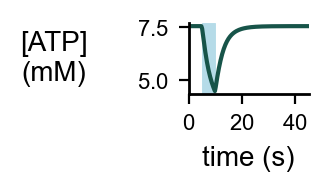

In [20]:
stim_idx = -1
tsim = np.linspace(0, 600, 2000)
test_auc, act,sol = compute_pAMPK_act_AUC(0.1, 2e0, params[0])

Ca = sol[4]
ATP = sol[2]

fig, ax = get_sized_fig_ax(width/2.5, height/3.5)
ax.plot(tsim, act, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, 45)
# ax.set_ylim(-1.5, 1.5)
# ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel('pAMPK\nactivty\n'+r'(mM/s)', fontsize=10, rotation=0, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 10, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'pAMPK_act.pdf', bbox_inches='tight', transparent=True)

fig, ax = get_sized_fig_ax(width/2.5, height/3.5)
ax.plot(tsim, ATP, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, 45)
# ax.set_ylim(0, 1.5)
# ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel('[ATP]\n(mM)', fontsize=10, rotation=0, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 10, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'ATP.pdf', bbox_inches='tight', transparent=True)

### Now vary the duration of the step function

In [21]:
Ca_level = 0.1
ATP_flux_level = 2.0
tsim = np.linspace(0, 600, 4000)

Ca_force = lambda t, stim_length: 0.1 + step_signal(t, 5, 0.0, Ca_level, reverse=True,
                                            reverse_time=5+stim_length)
# baseline plus pulse

kHydro = lambda t, stim_length: step_signal(t, 5, 0.0, ATP_flux_level, reverse=True,
                                            reverse_time=5+stim_length)
# pulse only

@jax.jit
def compute_pAMPK_act_AUC_stim_len(stim_len, param):
    Ca_stim = lambda t: Ca_force(t, stim_len)    
    kHydro_stim = lambda t: kHydro(t, stim_len)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC_stim_len = jax.vmap(compute_pAMPK_act_AUC_stim_len, in_axes=(None, 0))

stim_lens = [0.5, 1.0, 2.0,3.0,4.0,5.0, 10.0,15.0, 20.0, 30.0]

auc_vals_stim_len = []
acts_stim = []
sols_stim_len = []
for stim_len in stim_lens:
    # compute the AUC
    auc, pAMPK_act, sol = vmap_compute_pAMPK_act_AUC_stim_len(stim_len, params)
    
    auc_vals_stim_len.append([auc])
    acts_stim.append([pAMPK_act])
    sols_stim_len.append([sol])

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1509016271.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/3990485067.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/3990485067.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that a

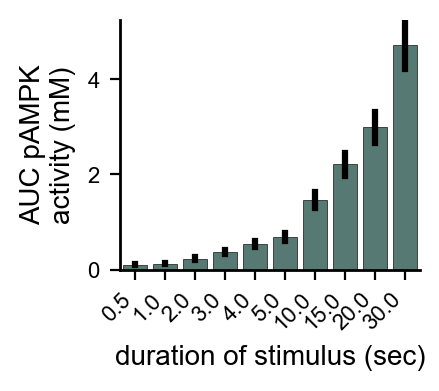

In [22]:
dat_df = pd.DataFrame(auc_vals_stim_len, columns=['AUC'])

# Add kHydro and Ca columns
dat_df['stim_length'] = stim_lens

# Expand the dataframe to have one row per replicate
dat_df_expanded = dat_df.explode('AUC').reset_index(drop=True)
dat_df_expanded['replicates'] = 0

# Assign replicate index (starting from 1) for each group
for i in range(len(stim_lens)):
    n_reps = len(dat_df.loc[i, 'AUC'])
    dat_df_expanded.loc[dat_df_expanded.index[sum(len(dat_df.loc[j, 'AUC']) for j in range(i)):sum(len(dat_df.loc[j, 'AUC']) for j in range(i+1))], 'replicates'] = range(1, n_reps+1)

dat_df = dat_df_expanded

dat_df['AUC'] = dat_df['AUC'].astype(float)

fig, ax = plot_barplot(dat_df, 'stim_length', 'AUC', 'duration of stimulus (sec)', 
                       'AUC pAMPK\nactivity (mM)', width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

xticklabs = [str(i) for i in stim_lens]
ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
ax.set_ylim([0, 5.25])


fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len.pdf', bbox_inches='tight', transparent=True)

ATP hyrolysis only

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1509016271.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/2093512776.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/2093512776.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_hydro_only.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes 

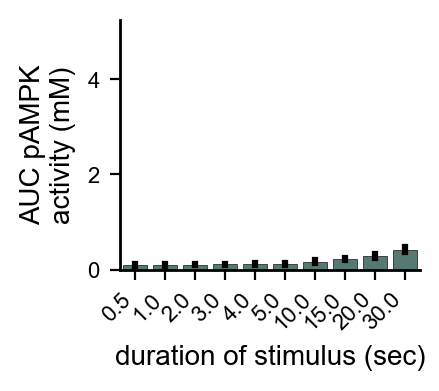

In [23]:
Ca_level = 0.0
ATP_flux_level = 2.0
tsim = np.linspace(0, 600, 4000)

Ca_force = lambda t, stim_length: 0.1 + step_signal(t, 5, 0.0, Ca_level, reverse=True,
                                            reverse_time=5+stim_length)
# baseline plus pulse

kHydro = lambda t, stim_length: step_signal(t, 5, 0.0, ATP_flux_level, reverse=True,
                                            reverse_time=5+stim_length)
# pulse only

@jax.jit
def compute_pAMPK_act_AUC_stim_len(stim_len, param):
    Ca_stim = lambda t: Ca_force(t, stim_len)    
    kHydro_stim = lambda t: kHydro(t, stim_len)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC_stim_len = jax.vmap(compute_pAMPK_act_AUC_stim_len, in_axes=(None, 0))

stim_lens = [0.5, 1.0, 2.0,3.0,4.0,5.0, 10.0,15.0, 20.0, 30.0]

auc_vals_stim_len_hydro = []
acts_stim_hydro = []
sols_stim_len_hydro = []
for stim_len in stim_lens:
    # compute the AUC
    auc, pAMPK_act, sol = vmap_compute_pAMPK_act_AUC_stim_len(stim_len, params)
    
    auc_vals_stim_len_hydro.append([auc])
    acts_stim_hydro.append([pAMPK_act])
    sols_stim_len_hydro.append([sol])

dat_df_hydro = pd.DataFrame(auc_vals_stim_len_hydro, columns=['AUC'])

# Add kHydro and Ca columns
dat_df_hydro['stim_length'] = stim_lens

# Expand the dataframe to have one row per replicate
dat_df_hydro_expanded = dat_df_hydro.explode('AUC').reset_index(drop=True)
dat_df_hydro_expanded['replicates'] = 0

# Assign replicate index (starting from 1) for each group
for i in range(len(stim_lens)):
    n_reps = len(dat_df_hydro.loc[i, 'AUC'])
    dat_df_hydro_expanded.loc[dat_df_hydro_expanded.index[sum(len(dat_df_hydro.loc[j, 'AUC']) for j in range(i)):sum(len(dat_df_hydro.loc[j, 'AUC']) for j in range(i+1))], 'replicates'] = range(1, n_reps+1)

dat_df_hydro = dat_df_hydro_expanded

dat_df_hydro['AUC'] = dat_df_hydro['AUC'].astype(float)

fig, ax = plot_barplot(dat_df_hydro, 'stim_length', 'AUC', 'duration of stimulus (sec)', 
                       'AUC pAMPK\nactivity (mM)', width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

xticklabs = [str(i) for i in stim_lens]
ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
ax.set_ylim([0, 5.25])


fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_hydro_only.pdf', bbox_inches='tight', transparent=True)

<!-- Calcium only -->

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1509016271.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/4245137117.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/4245137117.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_calcium_only.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure include

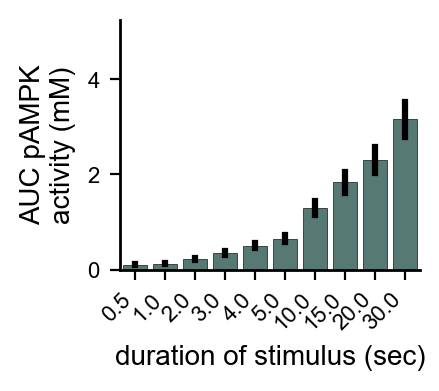

In [24]:
Ca_level = 0.1
ATP_flux_level = 0.0
tsim = np.linspace(0, 600, 4000)

Ca_force = lambda t, stim_length: 0.1 + step_signal(t, 5, 0.0, Ca_level, reverse=True,
                                            reverse_time=5+stim_length)
# baseline plus pulse

kHydro = lambda t, stim_length: step_signal(t, 5, 0.0, ATP_flux_level, reverse=True,
                                            reverse_time=5+stim_length)
# pulse only

@jax.jit
def compute_pAMPK_act_AUC_stim_len(stim_len, param):
    Ca_stim = lambda t: Ca_force(t, stim_len)    
    kHydro_stim = lambda t: kHydro(t, stim_len)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC_stim_len = jax.vmap(compute_pAMPK_act_AUC_stim_len, in_axes=(None, 0))

stim_lens = [0.5, 1.0, 2.0,3.0,4.0,5.0, 10.0,15.0, 20.0, 30.0]

auc_vals_stim_len_calcium = []
acts_stim_calcium = []
sols_stim_len_calcium = []
for stim_len in stim_lens:
    # compute the AUC
    auc, pAMPK_act, sol = vmap_compute_pAMPK_act_AUC_stim_len(stim_len, params)
    
    auc_vals_stim_len_calcium.append([auc])
    acts_stim_calcium.append([pAMPK_act])
    sols_stim_len_calcium.append([sol])

dat_df_calcium = pd.DataFrame(auc_vals_stim_len_calcium, columns=['AUC'])

# Add kHydro and Ca columns
dat_df_calcium['stim_length'] = stim_lens

# Expand the dataframe to have one row per replicate
dat_df_calcium_expanded = dat_df_calcium.explode('AUC').reset_index(drop=True)
dat_df_calcium_expanded['replicates'] = 0

# Assign replicate index (starting from 1) for each group
for i in range(len(stim_lens)):
    n_reps = len(dat_df_calcium.loc[i, 'AUC'])
    dat_df_calcium_expanded.loc[dat_df_calcium_expanded.index[sum(len(dat_df_calcium.loc[j, 'AUC']) for j in range(i)):sum(len(dat_df_calcium.loc[j, 'AUC']) for j in range(i+1))], 'replicates'] = range(1, n_reps+1)

dat_df_calcium = dat_df_calcium_expanded

dat_df_calcium['AUC'] = dat_df_calcium['AUC'].astype(float)

fig, ax = plot_barplot(dat_df_calcium, 'stim_length', 'AUC', 'duration of stimulus (sec)', 
                       'AUC pAMPK\nactivity (mM)', width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

xticklabs = [str(i) for i in stim_lens]
ax.set_xticklabels(xticklabs, fontsize=8, rotation=45, ha='right')
ax.set_ylim([0, 5.25])


fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_calcium_only.pdf', bbox_inches='tight', transparent=True)

plots of transients for NPJ Sys Biol Revision

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1072416065.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_05_transient.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1072416065.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_05_CaMKK2_transient.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1072416065.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_05_pAMPK_act_transient.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/1072416065.py:64: UserWarning: This figure includes Axes that are not

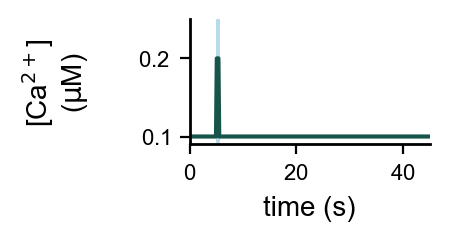

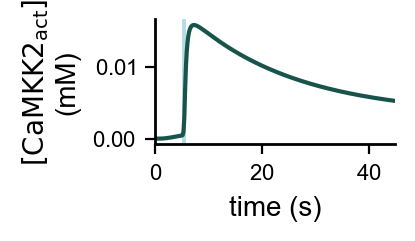

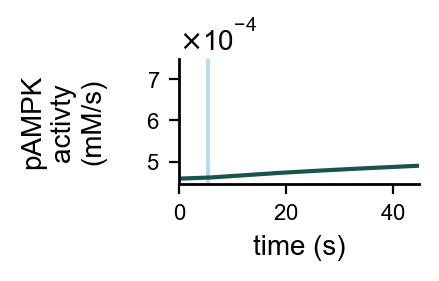

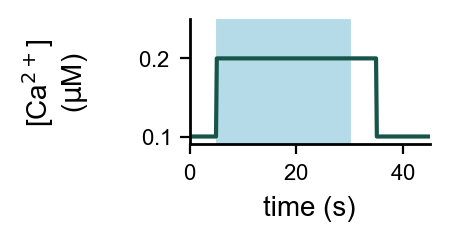

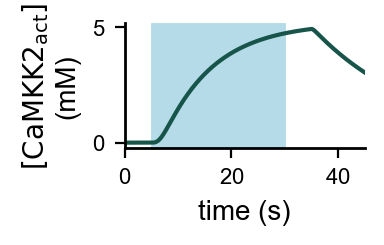

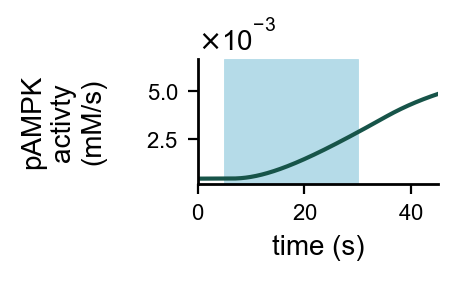

In [25]:
# 0.5 sec pulse of Ca2+
tmp_sol = sols_stim_len_calcium[0][0][0]

# plot Ca2+, CaMKK2, AMPK activity
# Ca2+
xmax = 45
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, Ca_force(tsim, 0.5), color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
ax.set_ylim(0.09, 1.25*max(Ca_force(tsim, 0.5)))
# ax.set_yticks([0])
# ax.set_xticks([0, 20])
ax.set_ylabel(r'[Ca$^{2+}$]'+'\n'+r'($\mu$M)', fontsize=10, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 5.5, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_05_transient.pdf', bbox_inches='tight', transparent=True)

# CaMKK2
CaMKK2 = tmp_sol[8]
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, CaMKK2, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
# ax.set_ylim(0, 1.5)
# ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 5.5, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_05_CaMKK2_transient.pdf', bbox_inches='tight', transparent=True)

# pAMPK
pAMPK = acts_stim_calcium[0][0][0]
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, pAMPK, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
ax.set_xticks([0, 20, 40])
ax.set_ylabel('pAMPK\nactivty\n'+r'(mM/s)', fontsize=10, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 5.5, color='lightblue', alpha=0.9, zorder=0)
fig.savefig(save_dir + 'Ca_05_pAMPK_act_transient.pdf', bbox_inches='tight', transparent=True)

# 30 sec pulse of Ca2+
tmp_sol = sols_stim_len_calcium[-1][0][0]

# plot Ca2+, CaMKK2, AMPK activity
# Ca2+
xmax = 45
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, Ca_force(tsim, 30), color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
ax.set_ylim(0.09, 1.25*max(Ca_force(tsim, 30)))
# ax.set_yticks([0])
# ax.set_xticks([0, 20])
ax.set_ylabel(r'[Ca$^{2+}$]'+'\n'+r'($\mu$M)', fontsize=10, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 30, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_30_transient.pdf', bbox_inches='tight', transparent=True)

# CaMKK2
CaMKK2 = tmp_sol[8]
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, CaMKK2, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
# ax.set_ylim(0, 1.5)
# ax.set_yticks([0])
ax.set_xticks([0, 20, 40])
ax.set_ylabel(r'$[CaMKK2_{\rm act}]$' + '\n(mM)', fontsize=10)
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 30, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_30_CaMKK2_transient.pdf', bbox_inches='tight', transparent=True)

# pAMPK
pAMPK = acts_stim_calcium[-1][0][0]
fig, ax = get_sized_fig_ax(width/1.25, height/2)
ax.plot(tsim, pAMPK, color=plot_color, label='Ca2+ flux')
ax.set_xlim(0, xmax)
ax.set_xticks([0, 20, 40])
ax.set_ylabel('pAMPK\nactivty\n'+r'(mM/s)', fontsize=10, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 30, color='lightblue', alpha=0.9, zorder=0)
fig.savefig(save_dir + 'Ca_30_pAMPK_act_transient.pdf', bbox_inches='tight', transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_10764/4133658423.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_combined.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


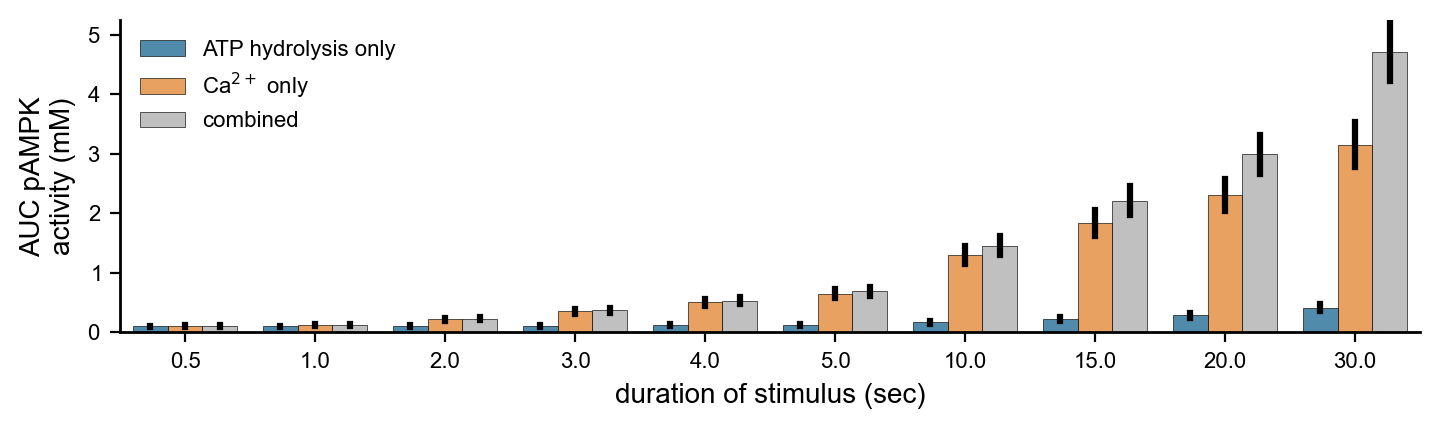

In [26]:
dat_df['type'] = 'combined'
dat_df_hydro['type'] = 'ATP hydrolysis only'
dat_df_calcium['type'] = r'Ca$^{2+}$ only'

dat = pd.concat([dat_df_hydro, dat_df_calcium, dat_df], ignore_index=True)

fig, ax = get_sized_fig_ax(6.5, 1.25*height)

sns.barplot(data=dat, 
            x='stim_length', y='AUC', hue='type',
            ax=ax, edgecolor='black', alpha=0.75,
            errorbar='sd',err_kws={'color': 'black'})

ax.set_xlabel('duration of stimulus (sec)', fontsize=10)
ax.set_ylabel('AUC pAMPK\nactivity (mM)', fontsize=10)
ax.set_ylim([0, 5.25])
ax.legend(title='', fontsize=8, title_fontsize=8)

ax.tick_params(axis='both', which='major', labelsize=8)

fig.savefig(save_dir + 'AUC_pAMPK_activity_stim_len_combined.pdf', bbox_inches='tight', transparent=True)
